In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Camera Matrix:

[[8.25126451e+04 0.00000000e+00 3.70641572e+02]
 [0.00000000e+00 8.25884297e+04 1.92693512e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Distortion coefficients:

[[-1.09445200e+02 -5.63078798e-04  2.93622749e-04 -2.22964184e-01
   3.37183513e-12]]


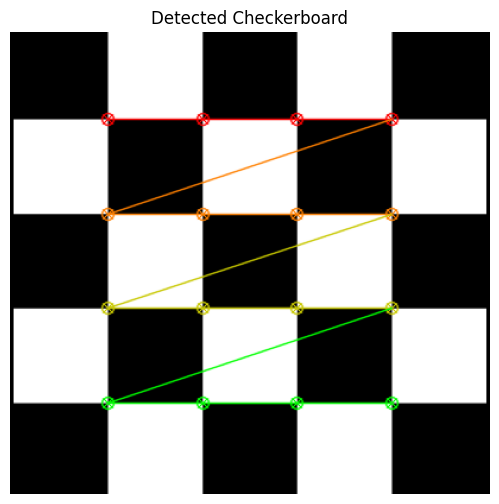

In [12]:
# Load checkerboard image
img = cv2.imread("checkerbox.png")
if img is None:
  print("Error: checkerbox.png not found")
  exit()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
checkerboard = (4,4)

# Find Checkerbox corner
ret, corners = cv2.findChessboardCorners(gray, checkerboard, None)
if ret:
  # Draw detected corners
  cv2.drawChessboardCorners(img, checkerboard, corners, ret)

  # Prepare object points
  objp = np.zeros((checkerboard[0]*checkerboard[1], 3), np.float32)
  objp[:, :2] = np.mgrid[0:checkerboard[0], 0:checkerboard[1]].T.reshape(-1, 2)
  objpoints = [objp]
  imgpoints = [corners]

  # camera calibration
  ret, cameraMatrix, distCoeffs, rvecs, tvecs = cv2.calibrateCamera(
      objpoints,
      imgpoints,
      gray.shape[::-1],
      None,
      None
  )

  print("Camera Matrix:\n")
  print(cameraMatrix)

  print("\nDistortion coefficients:\n")
  print(distCoeffs)

  # Convert BGR to RGB for displaying with matplotlib
  img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

  plt.figure(figsize=(8, 6))
  plt.imshow(img_rgb)
  plt.title("Detected Checkerboard")
  plt.axis("off")
  plt.show()
else:
  print("CheckerBoard not detected")